In [1]:
from pathlib import Path
from furax.interfaces.toast.observation import ToastObservation
import matplotlib.pyplot as plt

## Loading the data from toast

In [2]:
filename = Path("tests/data/test_obs.h5")
if not filename.exists():
    raise FileNotFoundError(f"{filename} does not exist")

obs = ToastObservation.from_file(filename)

## Get the TOD, HWP angles

In [3]:
import numpy as np
from furax.math.quaternion import to_lonlat_angles

In [27]:
tod = obs.get_tods() # shape: (n_detectors, n_samples)
sample_mask = obs.get_sample_mask() # shape: (n_samples,)
scanning_mask = obs.get_scanning_mask()

azimuth = obs.get_azimuth() # shape: (n_samples,)
elevation = obs.get_elevation() # shape: (n_samples,)

hwp_angles = obs.get_hwp_angles() # shape: (n_samples,)
time = obs.get_elapsed_times() # shape: (n_samples,)

# qfull = np.roll(obs._get_expanded_quats(), 1, axis=-1) # shape: (n_detectors, n_samples, 4) # quarternions

bor_quat = obs.get_boresight_quaternions() # shape: (n_samples, 4)
det_quat = obs.get_detector_quaternions() # shape: (n_samples, 4)

#### Quaternion
A quaternion is written as
$$
q = w + x i + y j + z k
$$
or as the vector form
$$
q = [w, x, y, z]
$$
where
- $w$ is the scalar part
- $[x, y, z]$ is the vector part
- Norm: $|q| = \sqrt{w^2 + x^2 + y^2 + z^2} = 1$ for the rotations (unit quaternions)

The reason to use quaternion is to represent 3D rotation without *gimbal lock*. 

#### Quaternion rotation of a vector
Let's say you have a 3D vector $v = [v_x, v_y, v_z]$ (e.g. pointing direction)

To rotate $v$ using quaternion $q$:
1. Represent $v$ as a pure quaternion
$$
v = [0, v_x, v_y, v_z]
$$. 
If $q = [w, x, y, z]$ is a **unit quaternion** representing a rotation, the rotated vector $v'$ is
$$
v'_q = q \cdot v_q \cdot q^{-1}
$$
- $q^{-1} = [w, -x, -y, -z]$ the inverse of a unit quaternion is its conjugate.
- To multiply the quaternion
$$
q_1 \cdot q_2 = [w_1, \mathbf{v}_1] \cdot [w_2, \mathbf{v}_2] = [w_1 w_2 - \mathbf{v}_1 \cdot \mathbf{v}_2]
$$

In [8]:
# lon, lat, _ = to_lonlat_angles(qfull) # convert the quarternions to lon, lat
lon_, lat_ = obs.get_detector_pointing_lonlat(thin_samples=10, use_scanning_mask=False, use_degrees=False) # get the detector lon, lat

In [9]:
colors = ["violet", "orange"]

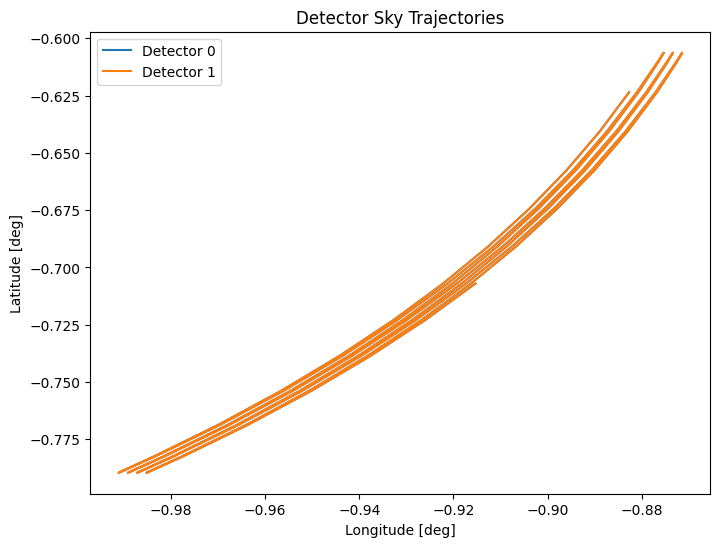

In [10]:
n_detectors = lon_.shape[0]

plt.figure(figsize=(8, 6))
for i in range(n_detectors):
    # plt.plot(lon[i, :], lat[i, :], color=colors[i], label=f'Detector qfull {i}')
    plt.plot(lon_[i, :], lat_[i, :], label=f'Detector {i}')

plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.title("Detector Sky Trajectories")
plt.legend()

# plt.xlim(lon.min(), lon.max())
# plt.ylim(lat.min(), lat.max())

plt.show()

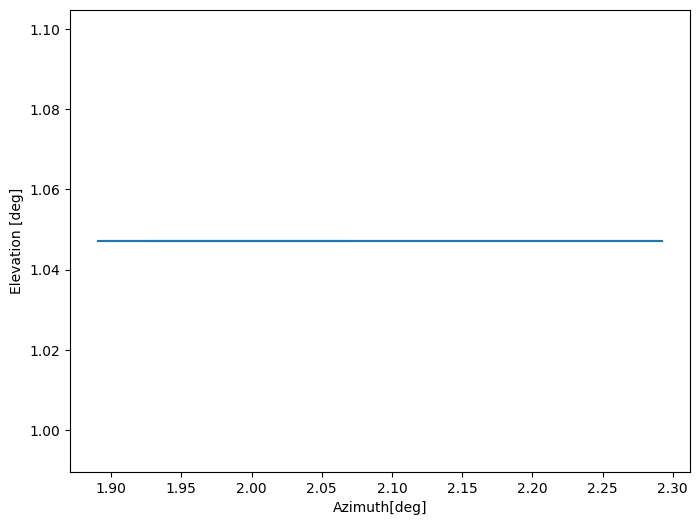

In [11]:
# Constant elevation scan
plt.figure(figsize=(8, 6))

plt.plot(azimuth, elevation)
plt.xlabel("Azimuth[deg]")
plt.ylabel("Elevation [deg]")
plt.show()

plt.close()

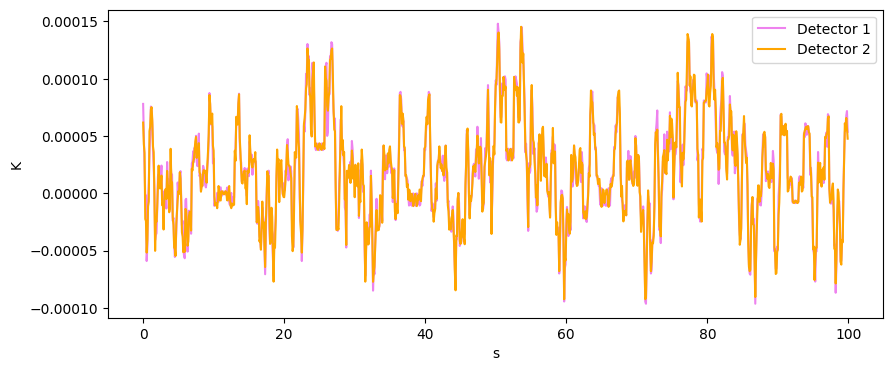

In [12]:
plt.figure(figsize=(10,4))
plt.plot(time, tod[0], color="violet", label="Detector 1")
plt.plot(time, tod[1], color="orange", label="Detector 2")

plt.xlabel("s")
plt.ylabel(r"K")
plt.legend()
plt.show()
plt.close()

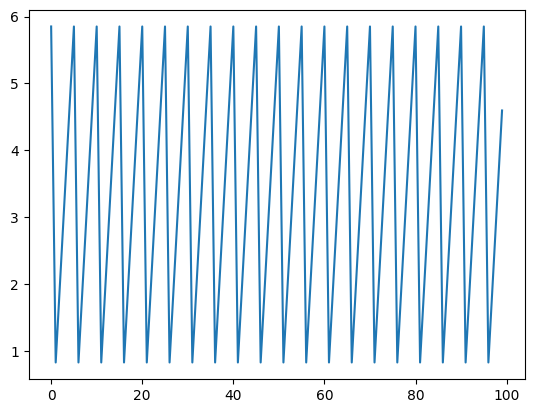

In [13]:
plt.figure()
plt.plot(hwp_angles[:100])

plt.show()
plt.close()

## Landscape info

In [14]:
from furax.obs.landscapes import HealpixLandscape

In [15]:
# Define sky resolution
nside = 512
landscape = HealpixLandscape(nside=nside, stokes='IQU')
n_pix = landscape.shape[0]

print(f"Sky map: {n_pix} pixels with {landscape.stokes} Stokes parameters")
print(f"Total sky parameters: {landscape.size}")

Sky map: 3145728 pixels with IQU Stokes parameters
Total sky parameters: 9437184


## Creating a Pointing operator

In [16]:
pointing, spin_angles = obs.get_pointing_and_spin_angles(landscape=landscape)

In [17]:
from furax.mapmaking.pointing import PointingOperator

In [28]:
point_op = PointingOperator.create(landscape, boresight_quaternions=bor_quat, detector_quaternions=det_quat)

In [34]:
point_op

PointingOperator(in_structure=StokesIQU(i=ShapeDtypeStruct(shape=(3145728,), dtype=float64), q=ShapeDtypeStruct(shape=(3145728,), dtype=float64), u=ShapeDtypeStruct(shape=(3145728,), dtype=float64)), landscape=<furax.obs.landscapes.HealpixLandscape object at 0x13835aa10>, qbore=Array([[0.47824209, 0.79878509, 0.33393437, 0.14735915],
       [0.47776648, 0.79869526, 0.33527273, 0.1463464 ],
       [0.47728943, 0.79860298, 0.33661007, 0.14533319],
       ...,
       [0.45613263, 0.7913618 , 0.39326521, 0.10503329],
       [0.45666338, 0.79155554, 0.3919797 , 0.10606743],
       [0.45719273, 0.79174688, 0.39069299, 0.10710125]], dtype=float64), qdet=Array([[-9.98722084e-01, -5.04932092e-02, -2.15297148e-03,
         2.43635220e-17],
       [-9.98722084e-01, -5.04932092e-02, -2.15297148e-03,
        -6.03172009e-17]], dtype=float64), chunk_size=16, _out_structure=StokesIQU(i=ShapeDtypeStruct(shape=(2, 1000), dtype=float64), q=ShapeDtypeStruct(shape=(2, 1000), dtype=float64), u=ShapeDtypeSt